In [19]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

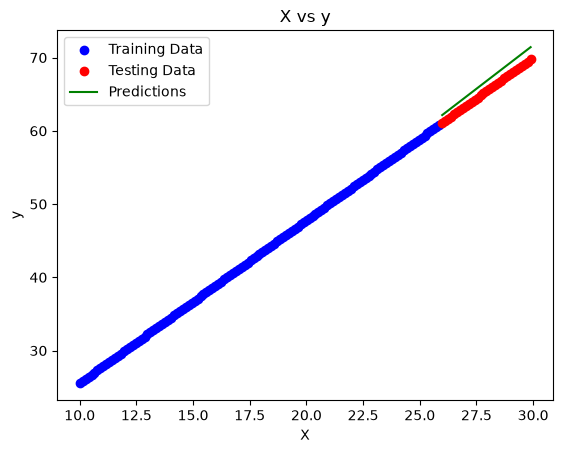

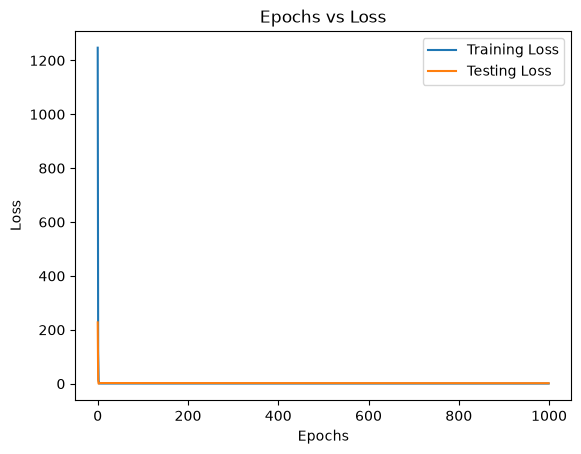

Finally w=2.3778290057270834 and b=0.3543612876543313


In [15]:
# Task-1:Implement the manual NumPy version of Linear Regression and record the 
# learned values of w and b. Compare them with the true values used to generate the 
# data.

# Step 1: Import Libraries
# Step 2: Generate Synthetic Data
X = np.arange(10, 30, 0.13)
y = 2.222 * X + 3.333

# Step 3: Train-Test Split
split = int(len(X) * 0.8)
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

# Step 4: Visualize the Data Function
def plot_data(X_train, y_train, X_test, y_test, predictions=None):
    plt.scatter(X_train, y_train, c='b', label='Training Data')
    plt.scatter(X_test, y_test, c='r', label='Testing Data')
    if predictions is not None:
        plt.plot(X_test, predictions, c='g', label='Predictions')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title('X vs y')
    plt.legend()
    plt.show()

# Step 5: Initialize Parameters
np.random.seed(42)  
w = np.random.randn()
b = np.random.randn()

# Step 6: Define the Loss Function (Fixed typo: y_actual - y_out)
def loss_fn(y_actual, y_out):
    return np.sum(np.square(y_actual - y_out)) / len(y_actual)

# Step 8: Training Loop (Manual Gradient Descent)
lr = 0.001
epochs = 1000  # Increased epochs to give the smaller lr time to converge
train_loss_list, test_loss_list = [], []

for epoch in range(epochs):
    # Forward pass
    train_preds = X_train * w + b
    train_loss = loss_fn(y_train, train_preds)
    
    # Compute gradients (Fixed the partial derivative math formulas)
    gradientw = (-2 / len(X_train)) * np.sum((y_train - train_preds) * X_train)
    gradientb = (-2 / len(X_train)) * np.sum(y_train - train_preds)
    
    # Update parameters
    w = w - (gradientw * lr)
    b = b - (gradientb * lr)
    
    # Evaluate on test data
    test_preds = X_test * w + b
    test_loss = loss_fn(y_test, test_preds)
    
    train_loss_list.append(train_loss)
    test_loss_list.append(test_loss)

# Step 9: Visualize Predictions After Training
y_out = X_test*w + b
plot_data(X_train, y_train, X_test, y_test, predictions=y_out)

# Step 10: Plot Loss Curves
plt.plot(range(epochs), train_loss_list, label="Training Loss")
plt.plot(range(epochs), test_loss_list, label="Testing Loss")
plt.title("Epochs vs Loss");
plt.xlabel("Epochs");
plt.ylabel("Loss")
plt.legend();
plt.show()

# Step 11: Check the Learned Parameters
print(f'Finally w={w} and b={b}')

--- Visualizing Predictions BEFORE Training ---


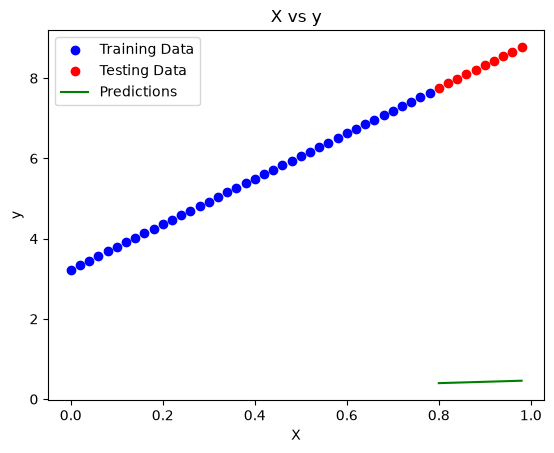

--- Visualizing Predictions AFTER Training ---


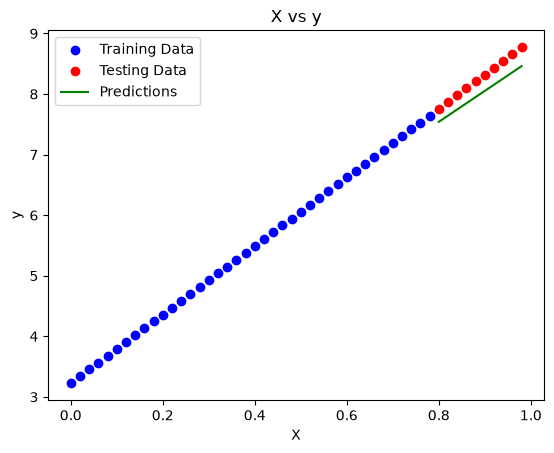

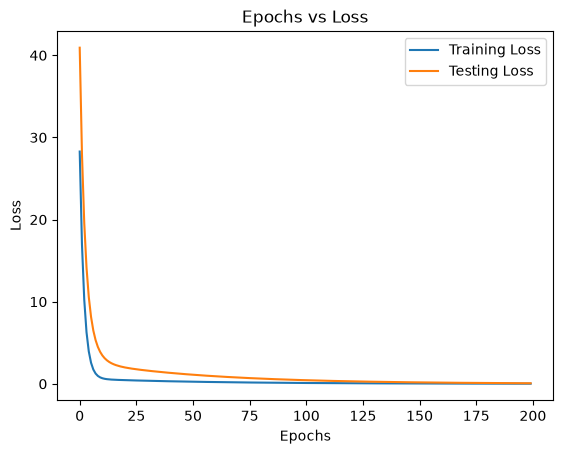

--- Task-2 Final Parameter Comparison ---
PyTorch Learned Weight (w): 5.1120 (True Equation Value: 5.6600)
PyTorch Learned Bias (b):   3.4510 (True Equation Value: 3.2270)


In [ ]:
# Task-2: Implement the PyTorch version using nn.Module and compare its learned 
# parameters with Part A. 

# Step 1: Import Libraries and Check Device
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

# Step 2: Generate Data and Convert to Tensors
X = np.arange(0, 1, 0.02)
y = 5.66 * X + 3.227

split = int(len(X) * 0.8)
X_train_np, y_train_np = X[:split], y[:split]
X_test_np, y_test_np = X[split:], y[split:]

#Convertnumpy arrays to PyTorch Tensors and cast to float32
X_train = torch.from_numpy(X_train_np).float().to(device)
y_train = torch.from_numpy(y_train_np).float().to(device)
X_test = torch.from_numpy(X_test_np).float().to(device)
y_test = torch.from_numpy(y_test_np).float().to(device)


# Step 3: Define the Model Class
class LinearRegressionNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

# Step 4: Instantiate the Model
torch.manual_seed(42)  
model_1 = LinearRegressionNetwork().to(device)
model_1.state_dict()

# Step 5: Predictions Before Training
with torch.inference_mode():
    y_pred = model_1(X_test)
print("--- Visualizing Predictions BEFORE Training ---")
plot_data(
    X_train=X_train.cpu().numpy(), 
    y_train=y_train.cpu().numpy(), 
    X_test=X_test.cpu().numpy(), 
    y_test=y_test.cpu().numpy(), 
    predictions=y_pred.cpu().numpy()
)

# Step 6: Define Loss Function and Optimizer
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)


# Step 7: Training Loop
epochs = 200
train_loss_list, test_loss_list = [], []

for epoch in range(epochs):
    model_1.train()
    
    # 1. Forward pass
    train_pred = model_1(X_train)
    
    # 2. Calculate Loss
    loss = loss_fn(train_pred, y_train)
    
    # 3. Optimizer zero grad
    optimizer.zero_grad()
    
    # 4. Perform backpropagation
    loss.backward()
    
    # 5. Update weights and biases
    optimizer.step()
    
    # Evaluate on test data
    model_1.eval()
    with torch.inference_mode():
        test_pred = model_1(X_test)
        test_loss = loss_fn(test_pred, y_test)
    
    # Track losses (moving back to CPU for numpy conversions if using GPU/MPS)
    train_loss_list.append(loss.cpu().detach().numpy())
    test_loss_list.append(test_loss.cpu().detach().numpy())

# Step 8: Predictions After Training
with torch.inference_mode():
    y_pred = model_1(X_test)
print("--- Visualizing Predictions AFTER Training ---")
plot_data(
    X_train=X_train.cpu().numpy(), 
    y_train=y_train.cpu().numpy(), 
    X_test=X_test.cpu().numpy(), 
    y_test=y_test.cpu().numpy(), 
    predictions=y_pred.cpu().numpy()
)

# Step 9: Plot Loss Curves
plt.plot(range(epochs), train_loss_list, label="Training Loss")
plt.plot(range(epochs), test_loss_list, label="Testing Loss")
plt.title("Epochs vs Loss");
plt.xlabel("Epochs");
plt.ylabel("Loss")
plt.legend();
plt.show()

# saving model
torch.manual_seed(42)
model = LinearRegressionNetwork()

print(f"--- Task-2 Final Parameter Comparison ---")
print(f"PyTorch Learned Weight (w): {model_1.weights.item():.4f} (True Equation Value: 5.6600)")
print(f"PyTorch Learned Bias (b):   {model_1.bias.item():.4f} (True Equation Value: 3.2270)")

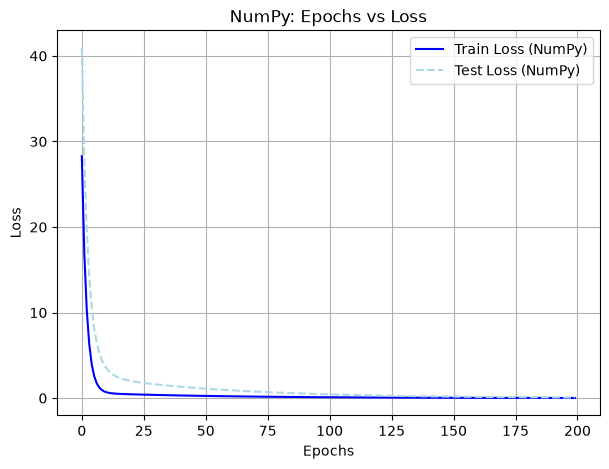

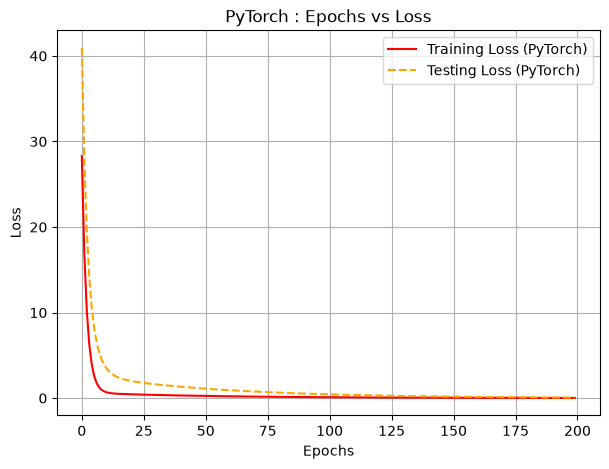

In [40]:
# Task-3: Plot and compare the loss curves (training vs testing) for both implementations. 
# Comment on convergence speed. 


plt.figure(figsize=(7, 5))

# 1. Plot NumPy Loss Curves 
plt.plot(train_loss_list, label="Train Loss (NumPy)", color="blue")
plt.plot(test_loss_list, label="Test Loss (NumPy)", color="lightblue", linestyle="--")
plt.title("NumPy: Epochs vs Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# 2. Plot PyTorch Loss Curves 
plt.figure(figsize=(7, 5))
plt.plot(train_loss_list, label="Training Loss (PyTorch)", color="red")
plt.plot(test_loss_list, label="Testing Loss (PyTorch)", color="orange", linestyle="--")
plt.title("PyTorch : Epochs vs Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

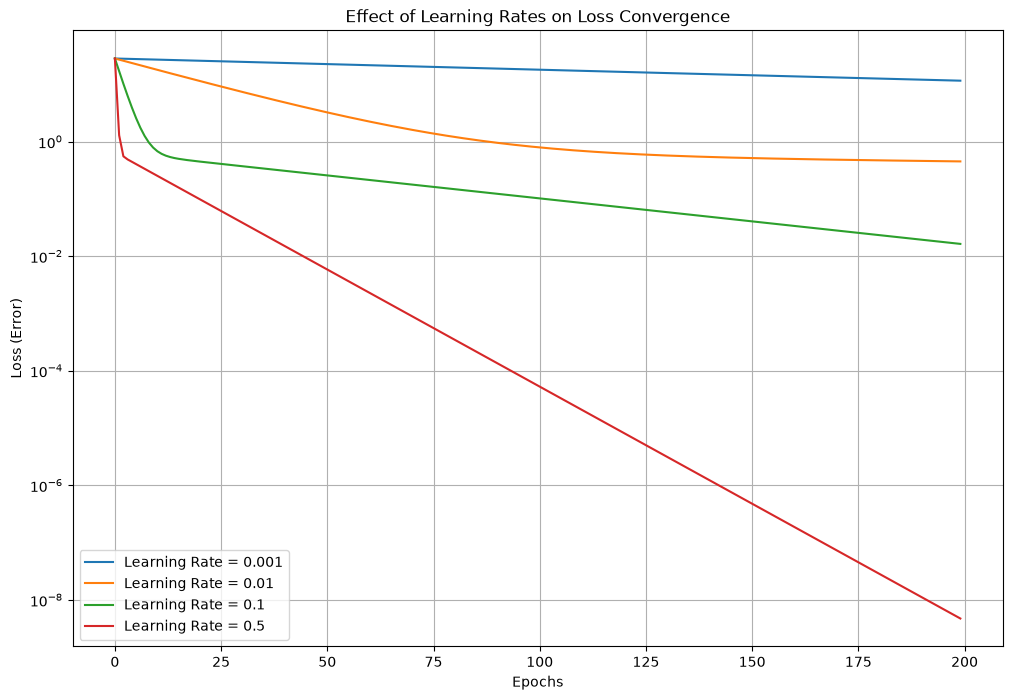

In [41]:
# Task-4: Experiment with different learning rates (e.g., 0.001, 0.01, 0.1, 0.5) and observe 
# their effect on convergence and stability. 

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
X = np.arange(0, 1, 0.02)
y = 5.66 * X + 3.227

split = int(len(X) * 0.8)
X_train = torch.from_numpy(X[:split]).float().to(device)
y_train = torch.from_numpy(y[:split]).float().to(device)

# Define Model Blueprint
class LinearRegressionNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

# The 4 learning rates to test
learning_rates = [0.001, 0.01, 0.1, 0.5]
epochs = 200

plt.figure(figsize=(12, 8))

# Run the loop for each learning rate
for lr in learning_rates:
    torch.manual_seed(42) # Reset seed so every model starts at the exact same wrong guess
    model = LinearRegressionNetwork().to(device)
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.SGD(params=model.parameters(), lr=lr)
    
    track_loss = []
    
    for epoch in range(epochs):
        model.train()
        preds = model(X_train)
        loss = loss_fn(preds, y_train)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        track_loss.append(loss.item())
        
    plt.plot(range(epochs), track_loss, label=f"Learning Rate = {lr}")

plt.title("Effect of Learning Rates on Loss Convergence")
plt.xlabel("Epochs")
plt.ylabel("Loss (Error)")
plt.yscale("log") # Using log scale makes it easier to see small errors
plt.legend()
plt.grid(True)
plt.show()

In [44]:
# Task-5:  Experiment with different numbers of epochs and determine the minimum epochs 
# needed for convergence in each implementation. 


device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

# Experiment 1: NumPy Version (Part A Data & Setup)
np.random.seed(42)
X_A = np.linspace(10, 30, 50)
y_A = 2.222 * X_A + 3.333

# Train-test split (80-20)
split_A = int(len(X_A) * 0.8)
X_train_A, y_train_A = X_A[:split_A], y_A[:split_A]

# Initialize random parameters
w_A, b_A = np.random.randn(), np.random.randn()
lr_A = 0.001
epochs_limit = 1500
prev_loss_A = float('inf')
min_epoch_A = None

for epoch in range(1, epochs_limit + 1):
    # Forward Pass & Loss
    y_pred = w_A * X_train_A + b_A
    loss = np.mean((y_train_A - y_pred) ** 2)
    
    # Check for convergence (when change in loss becomes microscopically small)
    if abs(prev_loss_A - loss) < 1e-5 and min_epoch_A is None:
        min_epoch_A = epoch
    prev_loss_A = loss
    
    # Manual Gradient Calculation
    dw = (-2 / len(X_train_A)) * np.sum((y_train_A - y_pred) * X_train_A)
    db = (-2 / len(X_train_A)) * np.sum(y_train_A - y_pred)
    
    # Update Parameters
    w_A -= lr_A * dw
    b_A -= lr_A * db


# Experiment 2: PyTorch Version (Part B Data & Setup)
X_B = np.arange(0, 1, 0.02)
y_B = 5.66 * X_B + 3.227
split_B = int(len(X_B) * 0.8)

X_train_B = torch.from_numpy(X_B[:split_B]).float().to(device)
y_train_B = torch.from_numpy(y_B[:split_B]).float().to(device)

class LinearRegressionNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

torch.manual_seed(42)
model = LinearRegressionNetwork().to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)

prev_loss_B = float('inf')
min_epoch_B = None

for epoch in range(1, 500):
    model.train()
    preds = model(X_train_B)
    loss = loss_fn(preds, y_train_B)
    
    current_loss = loss.item()
    if abs(prev_loss_B - current_loss) < 1e-5 and min_epoch_B is None:
        min_epoch_B = epoch
    prev_loss_B = current_loss
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# --- Print Final Results ---
print(f"NumPy Implementation (Part A):")
print(f" Minimum Epochs for Convergence: ~{min_epoch_A} epochs")
print(f" Final Learned Parameters: w = {w_A:.3f}, b = {b_A:.3f}\n")

print(f"PyTorch Implementation (Part B):")
print(f" Minimum Epochs for Convergence: ~{min_epoch_B} epochs")
print(f" Final Learned Parameters: w = {model.weights.item():.3f}, b = {model.bias.item():.3f}")
print("==================================================")

NumPy Implementation (Part A):
 Minimum Epochs for Convergence: ~None epochs
 Final Learned Parameters: w = 2.367, b = 0.552

PyTorch Implementation (Part B):
 Minimum Epochs for Convergence: ~386 epochs
 Final Learned Parameters: w = 5.625, b = 3.241


In [45]:
# Task-6: Modify the train-test split ratio (70-30, 80-20, 90-10) and compare the final test 
# loss for each split. 

# Step 1: Check device
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

# Step 2: Generate the base data
X = np.arange(0, 1, 0.02)
y = 5.66 * X + 3.227

# Define the model class (same as before)
class LinearRegressionNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

# The three splits required by the lab: 70-30, 80-20, 90-10
split_ratios = [0.7, 0.8, 0.9]

print("--- COMPARING TRAIN-TEST SPLIT RATIOS ---")

for ratio in split_ratios:
    # Calculate the split point based on the current ratio
    split = int(len(X) * ratio)
    
    # Split the raw data into numpy arrays
    X_train_np, y_train_np = X[:split], y[:split]
    X_test_np, y_test_np = X[split:], y[split:]
    
    # Convert them to PyTorch Tensors
    X_train = torch.from_numpy(X_train_np).float().to(device)
    y_train = torch.from_numpy(y_train_np).float().to(device)
    X_test = torch.from_numpy(X_test_np).float().to(device)
    y_test = torch.from_numpy(y_test_np).float().to(device)
    
    # Reset the model and optimizer fresh for this specific split
    torch.manual_seed(42)
    model = LinearRegressionNetwork().to(device)
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)
    
    # Train for 150 epochs (plenty of time to converge)
    for epoch in range(150):
        model.train()
        train_pred = model(X_train)
        loss = loss_fn(train_pred, y_train)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    # Evaluate final performance on the held-out Test Data
    model.eval()
    with torch.inference_mode():
        final_test_pred = model(X_test)
        final_test_loss = loss_fn(final_test_pred, y_test)
        
    # Print out the results clearly
    train_percentage = int(ratio * 100)
    test_percentage = int((1 - ratio) * 100)
    print(f"Split {train_percentage}-{test_percentage} -> Final Test Loss: {final_test_loss.item():.7f}")

--- COMPARING TRAIN-TEST SPLIT RATIOS ---
Split 70-30 -> Final Test Loss: 0.3861948
Split 80-19 -> Final Test Loss: 0.1776299
Split 90-9 -> Final Test Loss: 0.0780908


In [47]:
# Task-7: Replace the optimizer in Part B with torch.optim.Adam and compare its 
# convergence behavior with SGD.

# Step 1: Check device
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

# Step 2: Generate Part B Data
X = np.arange(0, 1, 0.02)
y = 5.66 * X + 3.227
split = int(len(X) * 0.8)
X_train = torch.from_numpy(X[:split]).float().to(device)
y_train = torch.from_numpy(y[:split]).float().to(device)

# Define the model class
class LinearRegressionNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

# 1. RUNNING WITH SGD OPTIMIZER
print("--- TRAINING WITH SGD OPTIMIZER ---")
torch.manual_seed(42)  # Use same seed so they start at the same wrong guess
model_sgd = LinearRegressionNetwork().to(device)
loss_fn = nn.MSELoss()
optimizer_sgd = torch.optim.SGD(params=model_sgd.parameters(), lr=0.1)

for epoch in range(100):
    model_sgd.train()
    preds = model_sgd(X_train)
    loss_sgd = loss_fn(preds, y_train)
    
    optimizer_sgd.zero_grad()
    loss_sgd.backward()
    optimizer_sgd.step()
    
    # Print the loss every 20 steps to watch the progress
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1} -> SGD Loss: {loss_sgd.item():.6f}")

print(f"Final SGD parameters -> w: {model_sgd.weights.item():.3f}, b: {model_sgd.bias.item():.3f}")


# 2. RUNNING WITH ADAM OPTIMIZER
print("\n--- TRAINING WITH ADAM OPTIMIZER ---")
torch.manual_seed(42)  # Reset seed for a perfectly fair comparison
model_adam = LinearRegressionNetwork().to(device)
optimizer_adam = torch.optim.Adam(params=model_adam.parameters(), lr=0.1)

for epoch in range(100):
    model_adam.train()
    preds = model_adam(X_train)
    loss_adam = loss_fn(preds, y_train)
    
    optimizer_adam.zero_grad()
    loss_adam.backward()
    optimizer_adam.step()
    
    # Print the loss every 20 steps to watch the progress
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1} -> Adam Loss: {loss_adam.item():.6f}")

print(f"Final Adam parameters -> w: {model_adam.weights.item():.3f}, b: {model_adam.bias.item():.3f}")

--- TRAINING WITH SGD OPTIMIZER ---
Epoch 20 -> SGD Loss: 0.457577
Epoch 40 -> SGD Loss: 0.315386
Epoch 60 -> SGD Loss: 0.217964
Epoch 80 -> SGD Loss: 0.150635
Epoch 100 -> SGD Loss: 0.104104
Final SGD parameters -> w: 4.280, b: 3.791

--- TRAINING WITH ADAM OPTIMIZER ---
Epoch 20 -> Adam Loss: 7.604599
Epoch 40 -> Adam Loss: 0.675271
Epoch 60 -> Adam Loss: 0.123387
Epoch 80 -> Adam Loss: 0.114392
Epoch 100 -> Adam Loss: 0.082897
Final Adam parameters -> w: 4.440, b: 3.755


In [48]:
# Task-8: Add Gaussian noise to the synthetic data (y = wX + b + noise) and analyze 
# how it affects the learned parameters and loss curves. 

# Step 1: Check device
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

# Step 2: Generate data AND add Gaussian Noise
np.random.seed(42)
X = np.arange(0, 1, 0.02)

# True parameters are w = 5.66 and b = 3.227
# We add random noise with a mean of 0 and a standard deviation of 0.3
noise = np.random.normal(0, 0.3, len(X))
y = 5.66 * X + 3.227 + noise

# Split data (80-20)
split = int(len(X) * 0.8)
X_train = torch.from_numpy(X[:split]).float().to(device)
y_train = torch.from_numpy(y[:split]).float().to(device)

# Define the model class
class LinearRegressionNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

# Initialize model and optimizer (Using SGD with 0.1 learning rate)
torch.manual_seed(42)
model = LinearRegressionNetwork().to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)

print("--- TRAINING WITH NOISY DATA ---")

# Train for 150 epochs
for epoch in range(150):
    model.train()
    preds = model(X_train)
    loss = loss_fn(preds, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 30 == 0:
        print(f"Epoch {epoch+1} -> Loss: {loss.item():.5f}")

print("--Noise Report--")
print("True Target Parameters: w = 5.660,  b = 3.227")
print(f"Learned Parameters:     w = {model.weights.item():.3f}, b = {model.bias.item():.3f}")
print(f"Final Minimum Loss:     {loss.item():.5f}")


--- TRAINING WITH NOISY DATA ---
Epoch 30 -> Loss: 0.39515
Epoch 60 -> Loss: 0.25879
Epoch 90 -> Loss: 0.18045
Epoch 120 -> Loss: 0.13544
Epoch 150 -> Loss: 0.10959
--Noise Report--
True Target Parameters: w = 5.660,  b = 3.227
Learned Parameters:     w = 4.555, b = 3.608
Final Minimum Loss:     0.10959


In [50]:
# Task-9: Extend the model to Multiple Linear Regression using two or more input features 
# and evaluate performance. 

# Step 1: Check device
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

# Step 2: Generate data with TWO input features (X1 and X2)
np.random.seed(42)
# Creating 50 rows of data, each containing 2 random features
X = np.random.rand(50, 2)

# True underlying formula: y = 3.5*X1 + 1.8*X2 + 2.5
# X[:, 0] represents the first feature, X[:, 1] represents the second
y = 3.5 * X[:, 0] + 1.8 * X[:, 1] + 2.5

# Split data into Train and Test sets (80-20)
split = int(len(X) * 0.8)
X_train = torch.from_numpy(X[:split]).float().to(device)
y_train = torch.from_numpy(y[:split]).float().to(device).unsqueeze(1) # unsqueeze(1) aligns the dimensions

X_test = torch.from_numpy(X[split:]).float().to(device)
y_test = torch.from_numpy(y[split:]).float().to(device).unsqueeze(1)

# Define the Multiple Linear Regression Model
class MultipleLinearRegressionNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # in_features=2 means the model expects 2 inputs (X1 and X2)
        # out_features=1 means it returns 1 prediction (y)
        self.linear_layer = nn.Linear(in_features=2, out_features=1)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

# Initialize model, loss, and optimizer
torch.manual_seed(42)
model = MultipleLinearRegressionNetwork().to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)

print("--- TRAINING MULTIPLE LINEAR REGRESSION ---")

# Train for 200 epochs
for epoch in range(200):
    model.train()
    preds = model(X_train)
    loss = loss_fn(preds, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 40 == 0:
        print(f"Epoch {epoch+1} -> Train Loss: {loss.item():.6f}")

# Evaluate performance on hidden test data
model.eval()
with torch.inference_mode():
    test_preds = model(X_test)
    test_loss = loss_fn(test_preds, y_test)

# Pull out the learned values to check them
learned_weights = model.linear_layer.weight.detach().cpu().numpy()[0]
learned_bias = model.linear_layer.bias.detach().cpu().numpy()[0]

print("--EVALUATION REPORT--")
print("True Target Values:    w1 = 3.500,  w2 = 1.800,  b = 2.500")
print(f"Learned Parameters:     w1 = {learned_weights[0]:.3f},  w2 = {learned_weights[1]:.3f},  b = {learned_bias:.3f}")
print(f"Final Test Loss:        {test_loss.item():.6f}")


--- TRAINING MULTIPLE LINEAR REGRESSION ---
Epoch 40 -> Train Loss: 0.062366
Epoch 80 -> Train Loss: 0.016595
Epoch 120 -> Train Loss: 0.005297
Epoch 160 -> Train Loss: 0.001958
Epoch 200 -> Train Loss: 0.000792
--EVALUATION REPORT--
True Target Values:    w1 = 3.500,  w2 = 1.800,  b = 2.500
Learned Parameters:     w1 = 3.414,  w2 = 1.747,  b = 2.566
Final Test Loss:        0.001078


In [ ]:
# Task-10: Save the trained PyTorch model, reload it, and verify that predictions match. 

# i saved the model in task-2

# 1. Get predictions from your actual TRAINED model (model_1) using test data
model_1.eval()
with torch.inference_mode():
    preds_before = model_1(X_test)

# 2. Save the trained weights of model_1 to disk
torch.save(obj=model_1.state_dict(), f="linear_model.pth")
print("Model weights successfully saved to disk!")

# 3. Create a fresh model instance on the same device to test the reload
loaded_model = LinearRegressionNetwork().to(device)
loaded_model.load_state_dict(torch.load(f="linear_model.pth"))
loaded_model.eval() 

# 4. Get predictions from the reloaded model using the same test data
with torch.inference_mode():
    preds_after = loaded_model(X_test)

# 5. Verify they match perfectly
predictions_match = torch.allclose(preds_before, preds_after)
print(f"Do the predictions match perfectly? -> {predictions_match}")

Model weights successfully saved to disk!
Do the predictions match perfectly? -> True


##### Task-11: Discuss the advantages of using PyTorch's autograd and optimizers over manually computing gradients.
* **Autograd:** Eliminates the risk of manual calculus mistakes. It handles complex multi-layer chain rules automatically using dynamic computational graphs.
* **Optimizers:** Provides clean modularity. Swapping complex parameter update strategies (like adding momentum or switching from SGD to Adam) requires modifying exactly one line of setup code.